# ДЗ 4. Задание 7

In [34]:
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [35]:
records = SeqIO.parse("chr1.fna", "fasta")
record = next(records)
sequence_all = record.seq
sequence = sequence_all[10000:110000]

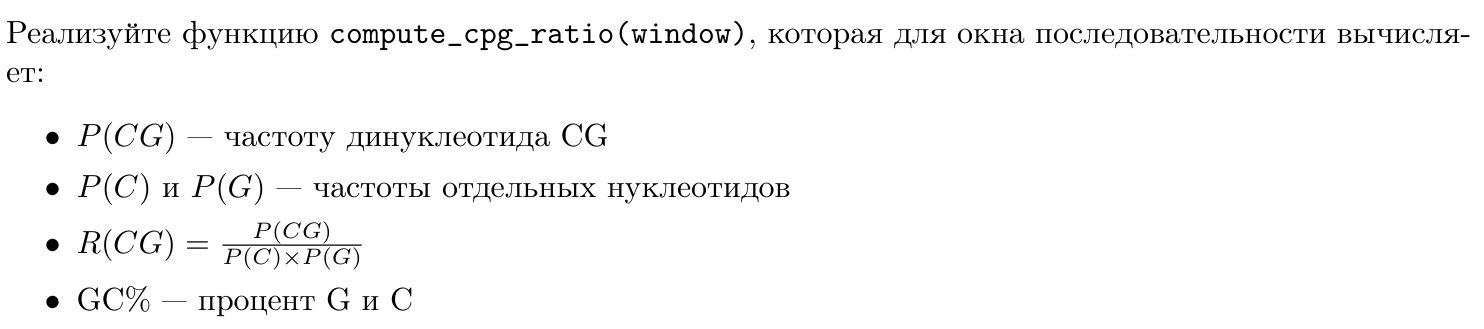

In [36]:
def compute_cpg_ratio(seq):
    n = len(seq)
    
    c = seq.count('C')
    g = seq.count('G')
    cg = sum(1 for i in range(n-1) if seq[i]=='C' and seq[i+1]=='G')
    
    r = (cg/(n-1)) / ((c/n)*(g/n)) if c>0 and g>0 else 0
    gc = (c+g)/n*100
    
    return {'R_CG': r, 'GC_percent': gc}

In [37]:
win = 200
step = 10
r_min = 0.6
gc_min = 50.0

pos = []
r_vals = []
gc_vals = []

islands = []
start = None

for i in range(0, len(sequence) - win + 1, step):
    m = compute_cpg_ratio(sequence[i:i+win])
    
    pos.append(i + win//2)
    r_vals.append(m['R_CG'])
    gc_vals.append(m['GC_percent'])
    
    mask = m['R_CG'] > r_min and m['GC_percent'] > gc_min
    if mask and start is None:
        start = i
    elif not mask and start is not None:
        islands.append((start, i+win))
        start = None
if start is not None:
    islands.append((start, len(sequence)))

In [38]:
print(f"Найдено CpG-островков: {len(islands)}")
for i, (s, e) in enumerate(islands, 1):
    print(f"  Остров {i}: {s}–{e} (длина {e-s} нт)")

Найдено CpG-островков: 10
  Остров 1: 940–1330 (длина 390 нт)
  Остров 2: 9220–9440 (длина 220 нт)
  Остров 3: 9250–9460 (длина 210 нт)
  Остров 4: 18630–19900 (длина 1270 нт)
  Остров 5: 19730–19940 (длина 210 нт)
  Остров 6: 26790–27030 (длина 240 нт)
  Остров 7: 78310–78590 (длина 280 нт)
  Остров 8: 78410–78620 (длина 210 нт)
  Остров 9: 78430–78640 (длина 210 нт)
  Остров 10: 78450–78660 (длина 210 нт)


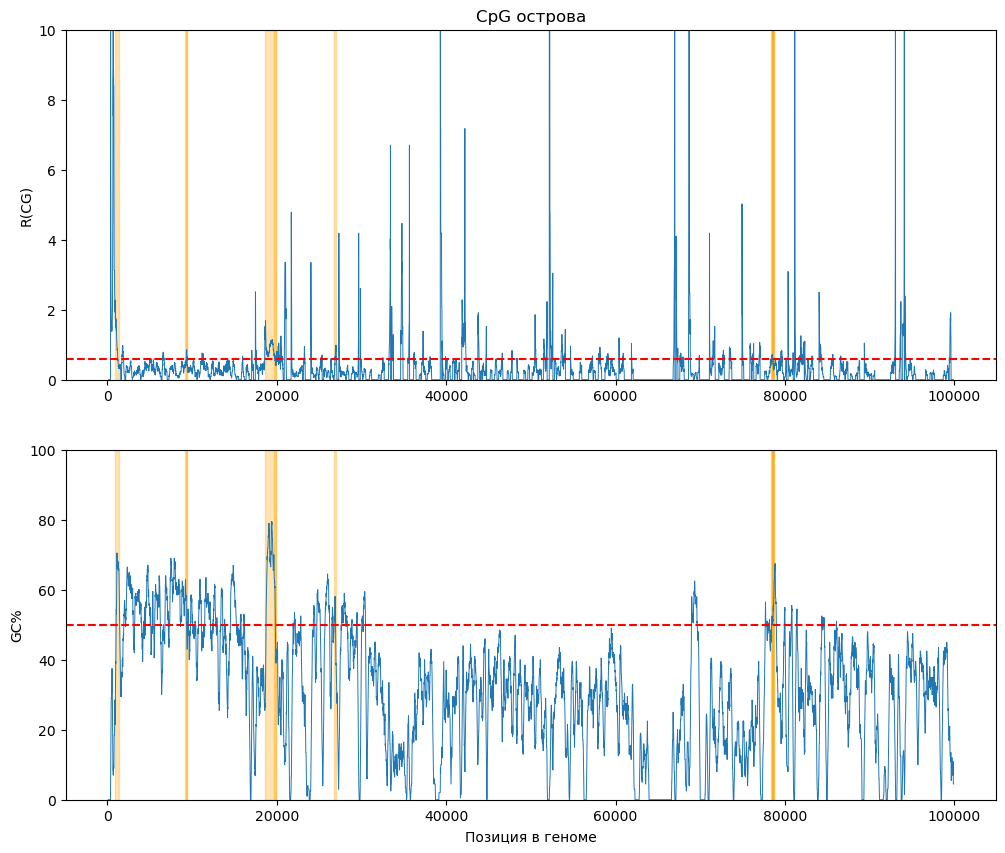

In [39]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(pos, r_vals, linewidth=0.7)
plt.axhline(y=0.6, color='r', ls='--')
for s, e in islands:
    plt.axvspan(s, e, alpha=0.3, color='orange')
plt.ylabel('R(CG)')
plt.title('CpG острова')
plt.ylim(0, 10)

plt.subplot(2, 1, 2)
plt.plot(pos, gc_vals, linewidth=0.7)
plt.axhline(y=50, color='r', ls='--')
for s, e in islands:
    plt.axvspan(s, e, alpha=0.3, color='orange')
plt.ylabel('GC%')
plt.xlabel('Позиция в геноме')
plt.ylim(0, 100);